# Task XI: MLP + Parameterized Quantum Circuit (PQC) Embedding

**Pipeline:**
1. **Generate normally distributed data** → target Pauli-Z expectation values via a fixed linear mapping + tanh
2. **MLP (3 Linear layers)** estimates PQC rotation parameters from the input
3. **PQC (5 qubits, 2 layers)** prepares a quantum state using those parameters
4. **Measure** ⟨Z⟩ on each qubit → compare with targets using **MSE Loss**
5. **Train end-to-end** via backpropagation through the quantum circuit

**Framework:** PyTorch + PennyLane

In [1]:
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## 1. Parameterized Quantum Circuit (5 qubits, 2 layers)

Each layer consists of:
- **Single-qubit rotations**: RX, RY, RZ on each qubit (3 × 5 = 15 params per layer)
- **Entangling layer**: circular CNOT ring (0→1→2→3→4→0)

Total PQC parameters: 2 layers × 15 = **30 rotation angles**

In [2]:
N_QUBITS = 5
N_LAYERS = 2
N_PQC_PARAMS = N_QUBITS * N_LAYERS * 3  # 30

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(params):
    """PQC: 2 layers of (RX, RY, RZ rotations + circular CNOT entangling)"""
    params = params.reshape(N_LAYERS, N_QUBITS, 3)
    for layer in range(N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
            qml.RZ(params[layer, q, 2], wires=q)
        for q in range(N_QUBITS):
            qml.CNOT(wires=[q, (q + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(q)) for q in range(N_QUBITS)]

# Draw the circuit
print("PQC Circuit Structure:")
drawer = qml.draw(quantum_circuit)
print(drawer(torch.zeros(N_PQC_PARAMS, dtype=torch.float64)))

PQC Circuit Structure:
0: ──RX(0.00)──RY(0.00)──RZ(0.00)─╭●──────────╭X──RX(0.00)──RY(0.00)──RZ(0.00)─╭●──────────╭X─┤  <Z>
1: ──RX(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●───────│───RX(0.00)──RY(0.00)──RZ(0.00)─╰X─╭●───────│──┤  <Z>
2: ──RX(0.00)──RY(0.00)──RZ(0.00)────╰X─╭●────│───RX(0.00)──RY(0.00)──RZ(0.00)────╰X─╭●────│──┤  <Z>
3: ──RX(0.00)──RY(0.00)──RZ(0.00)───────╰X─╭●─│───RX(0.00)──RY(0.00)──RZ(0.00)───────╰X─╭●─│──┤  <Z>
4: ──RX(0.00)──RY(0.00)──RZ(0.00)──────────╰X─╰●──RX(0.00)──RY(0.00)──RZ(0.00)──────────╰X─╰●─┤  <Z>


## 2. Data Generation

Input: normally distributed vectors (dim=8). Target: Pauli-Z expectations in [-1, 1] generated by a fixed linear mapping + tanh.

In [3]:
INPUT_DIM = 8
N_TRAIN = 800
N_TEST = 200

# Fixed target mapping (shared between train and test)
np.random.seed(0)
W_target = np.random.randn(INPUT_DIM, N_QUBITS).astype(np.float64) * 0.5
b_target = np.random.randn(N_QUBITS).astype(np.float64) * 0.1
np.random.seed(42)

def generate_data(n_samples, input_dim=8):
    X = np.random.randn(n_samples, input_dim).astype(np.float64)
    y = np.tanh(X @ W_target + b_target)
    return torch.tensor(X, dtype=torch.float64), torch.tensor(y, dtype=torch.float64)

X_train, y_train = generate_data(N_TRAIN, INPUT_DIM)
X_test, y_test = generate_data(N_TEST, INPUT_DIM)

print(f"Input dim: {INPUT_DIM}, Qubits: {N_QUBITS}, PQC params: {N_PQC_PARAMS}")
print(f"Train: {N_TRAIN}, Test: {N_TEST}")
print(f"Target range: [{y_train.min():.3f}, {y_train.max():.3f}]")

Input dim: 8, Qubits: 5, PQC params: 30
Train: 800, Test: 200
Target range: [-1.000, 1.000]


## 3. Hybrid MLP + PQC Model

The MLP maps classical input (dim=8) to 30 PQC rotation parameters. The PQC then prepares a quantum state, and we measure ⟨Z⟩ on each of the 5 qubits.

In [4]:
class HybridMLPPQC(nn.Module):
    def __init__(self, input_dim, n_pqc_params):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32, dtype=torch.float64),
            nn.Tanh(),
            nn.Linear(32, 32, dtype=torch.float64),
            nn.Tanh(),
            nn.Linear(32, n_pqc_params, dtype=torch.float64),
        )

    def forward(self, x):
        pqc_params = self.mlp(x)
        expectations = []
        for i in range(x.shape[0]):
            exp_vals = quantum_circuit(pqc_params[i])
            expectations.append(torch.stack(exp_vals))
        return torch.stack(expectations)

model = HybridMLPPQC(INPUT_DIM, N_PQC_PARAMS)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"  MLP: {INPUT_DIM} -> 32 -> 32 -> {N_PQC_PARAMS}")
print(f"  PQC: {N_LAYERS} layers x {N_QUBITS} qubits x 3 rotations")

Model parameters: 2,334
  MLP: 8 -> 32 -> 32 -> 30
  PQC: 2 layers x 5 qubits x 3 rotations


## 4. Training with MSE Loss

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-3)
criterion = nn.MSELoss()

EPOCHS = 80
BATCH_SIZE = 64
train_losses, test_losses = [], []

print(f"Training for {EPOCHS} epochs, batch_size={BATCH_SIZE}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    indices = torch.randperm(N_TRAIN)
    
    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx = indices[start:start + BATCH_SIZE]
        x_batch, y_batch = X_train[idx], y_train[idx]
        
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test).item()
    test_losses.append(test_loss)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train MSE: {avg_train_loss:.6f} | Test MSE: {test_loss:.6f}")

Training for 80 epochs, batch_size=64
-------------------------------------------------------


Epoch   1/80 | Train MSE: 0.804147 | Test MSE: 0.489062


Epoch  10/80 | Train MSE: 0.208007 | Test MSE: 0.200363


Epoch  20/80 | Train MSE: 0.060432 | Test MSE: 0.053715


Epoch  30/80 | Train MSE: 0.018528 | Test MSE: 0.019008


Epoch  40/80 | Train MSE: 0.014982 | Test MSE: 0.015770


Epoch  50/80 | Train MSE: 0.013608 | Test MSE: 0.014207


Epoch  60/80 | Train MSE: 0.012848 | Test MSE: 0.012998


Epoch  70/80 | Train MSE: 0.012120 | Test MSE: 0.012416


Epoch  80/80 | Train MSE: 0.011962 | Test MSE: 0.012039


## 5. Results & Visualization

Final Test MSE: 0.012039


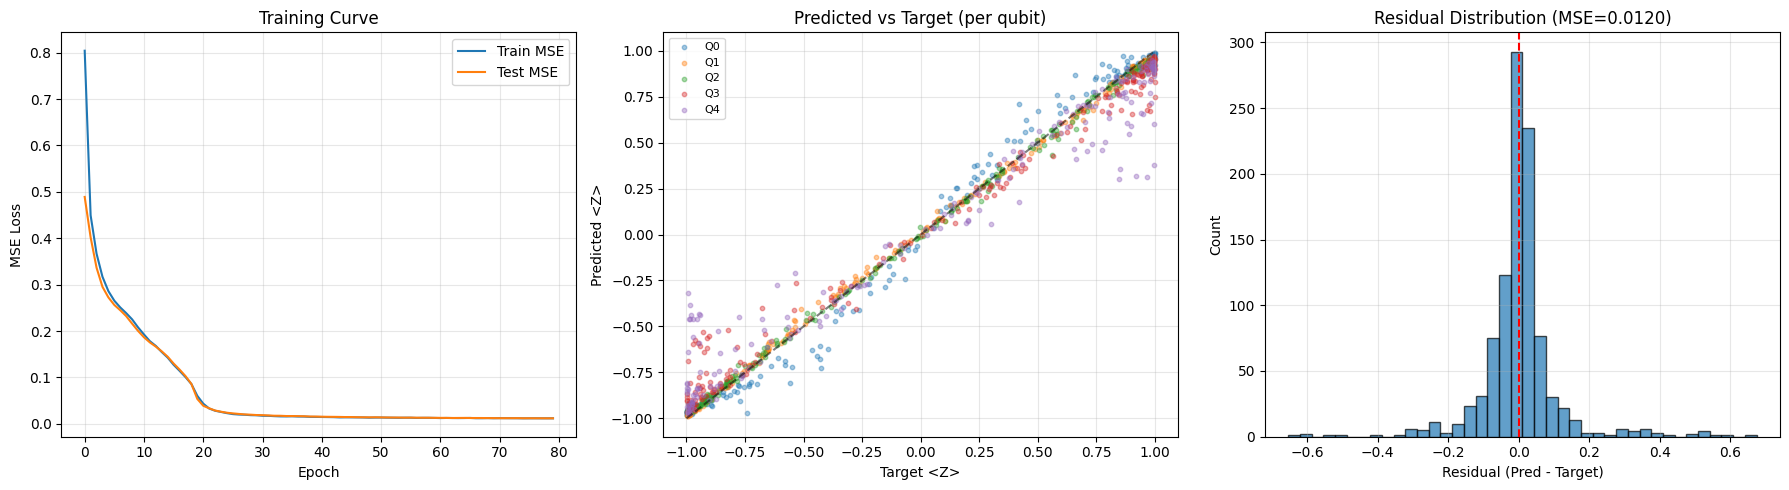

In [6]:
model.eval()
with torch.no_grad():
    final_pred = model(X_test).cpu().numpy()
    final_target = y_test.numpy()

final_mse = np.mean((final_pred - final_target) ** 2)
print(f"Final Test MSE: {final_mse:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training curve
axes[0].plot(train_losses, label="Train MSE")
axes[0].plot(test_losses, label="Test MSE")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Curve"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predicted vs Target per qubit
for q in range(N_QUBITS):
    axes[1].scatter(final_target[:, q], final_pred[:, q], alpha=0.4, s=10, label=f"Q{q}")
axes[1].plot([-1, 1], [-1, 1], "k--", alpha=0.5)
axes[1].set_xlabel("Target <Z>"); axes[1].set_ylabel("Predicted <Z>")
axes[1].set_title("Predicted vs Target (per qubit)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-1.1, 1.1); axes[1].set_ylim(-1.1, 1.1)

# Residual distribution
residuals = final_pred - final_target
axes[2].hist(residuals.flatten(), bins=40, edgecolor="black", alpha=0.7)
axes[2].axvline(0, color="red", linestyle="--")
axes[2].set_xlabel("Residual (Pred - Target)"); axes[2].set_ylabel("Count")
axes[2].set_title(f"Residual Distribution (MSE={final_mse:.4f})")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()